# Base versus fine-tuned model latency

Measures sequential client-observed latency on the same image set and writes
per-request and aggregate comparison artifacts.

In [1]:
from pathlib import Path
import json
import time
import pandas as pd
import matplotlib.pyplot as plt

from demo_common import (
    BASE_DEPLOYMENT, classification_prompt, classify,
    get_project_client, image_data_uri,
)

ROOT = Path.cwd()
OUTPUTS = ROOT / "outputs"
LATENCY_OUTPUTS = ROOT / "latency_outputs"
LATENCY_OUTPUTS.mkdir(exist_ok=True)

run_summary = json.loads((OUTPUTS / "run_summary.json").read_text(encoding="utf-8"))
ft_deployment = run_summary["fine_tuned_deployment"]
manifest = pd.read_csv(OUTPUTS / "dataset_manifest.csv")
test_df = manifest[manifest["split"] == "test"].head(8).copy()
labels = sorted(manifest["breed"].unique())
prompt = classification_prompt(labels)
project_client = get_project_client()
client = project_client.get_openai_client()
print("Comparing:", BASE_DEPLOYMENT, "vs", ft_deployment)

Comparing: image-breed-gpt-4o-base vs image-breed-gpt-4o-ft-340d2c52


In [2]:
records = []
for deployment, model_kind in (
    (BASE_DEPLOYMENT, "base"),
    (ft_deployment, "fine_tuned"),
):
    for row in test_df.itertuples(index=False):
        image_uri = image_data_uri(Path(row.image_path))
        started = time.perf_counter()
        prediction = classify(client, deployment, prompt, image_uri)
        latency_ms = (time.perf_counter() - started) * 1000
        records.append(
            {
                "model_kind": model_kind,
                "deployment": deployment,
                "image_id": row.id,
                "latency_ms": latency_ms,
                "prediction": prediction,
            }
        )
        print(model_kind, row.id, f"{latency_ms:.1f} ms")

latencies = pd.DataFrame(records)
latencies.to_csv(LATENCY_OUTPUTS / "per_request_latencies.csv", index=False)

base n02085620-Chihuahua-16 4956.8 ms


base n02085620-Chihuahua-17 1498.0 ms


base n02085620-Chihuahua-18 1973.3 ms


base n02085620-Chihuahua-19 1323.5 ms


base n02092339-Weimaraner-16 1871.9 ms


...

fine_tuned n02085620-Chihuahua-19 1549.9 ms


fine_tuned n02092339-Weimaraner-16 1394.2 ms


fine_tuned n02092339-Weimaraner-17 1593.0 ms


fine_tuned n02092339-Weimaraner-18 1418.5 ms


fine_tuned n02092339-Weimaraner-19 1678.6 ms


In [3]:
summary = (
    latencies.groupby(["model_kind", "deployment"])["latency_ms"]
    .agg(
        count="count",
        mean_ms="mean",
        median_ms="median",
        min_ms="min",
        max_ms="max",
        std_ms="std",
    )
    .reset_index()
)
for percentile in (0.90, 0.95, 0.99):
    values = (
        latencies.groupby(["model_kind", "deployment"])["latency_ms"]
        .quantile(percentile)
        .rename(f"p{int(percentile * 100)}_ms")
        .reset_index()
    )
    summary = summary.merge(values, on=["model_kind", "deployment"])

base_mean = float(summary.loc[summary["model_kind"] == "base", "mean_ms"].iloc[0])
ft_mean = float(
    summary.loc[summary["model_kind"] == "fine_tuned", "mean_ms"].iloc[0]
)
summary["throughput_rps"] = 1000 / summary["mean_ms"]
summary.to_csv(LATENCY_OUTPUTS / "latency_summary.csv", index=False)

latency_comparison = {
    "base_mean_ms": base_mean,
    "fine_tuned_mean_ms": ft_mean,
    "fine_tuned_minus_base_ms": ft_mean - base_mean,
    "fine_tuned_change_percent": ((ft_mean / base_mean) - 1) * 100,
    "requests_per_model": len(test_df),
}
(LATENCY_OUTPUTS / "latency_comparison.json").write_text(
    json.dumps(latency_comparison, indent=2), encoding="utf-8"
)
display(summary)
latency_comparison

,model_kind,deployment,count,mean_ms,median_ms,min_ms,max_ms,std_ms,p90_ms,p95_ms,p99_ms,throughput_rps
0,base,image-breed-gpt-4o-base,8,2120.741725,1827.36325,1323.4649,4956.8006,1175.356161,2938.94714,3947.87387,4755.015254,0.471533
1,fine_tuned,image-breed-gpt-4o-ft-340d2c52,8,1525.040900,1571.44360,1230.0239,1697.8095,163.437551,1684.36964,1691.08957,1696.465514,0.655720


{'base_mean_ms': 2120.741724909749,
 'fine_tuned_mean_ms': 1525.0408998690546,
 'fine_tuned_minus_base_ms': -595.7008250406943,
 'fine_tuned_change_percent': -28.089267921865645,
 'requests_per_model': 8}

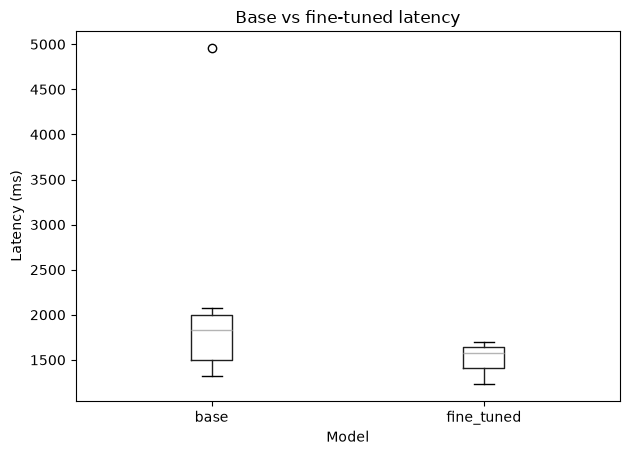

In [4]:
ax = latencies.boxplot(column="latency_ms", by="model_kind", grid=False)
ax.set_title("Base vs fine-tuned latency")
ax.set_xlabel("Model")
ax.set_ylabel("Latency (ms)")
plt.suptitle("")
plt.tight_layout()
plt.savefig(LATENCY_OUTPUTS / "latency_boxplot.png", dpi=150)
plt.show()

In [5]:
client.close()
project_client.close()